# 04 - Modelos de Deep Learning (LSTM, N-BEATS, N-HiTS)
## APEAJAL - Pronóstico de Precios de Aguacate Hass en Jalisco

**Nombres y matrículas:**
  * José Antonio Gómez Mora | A01374459
  * Alejandro Chávez Campos | A01374974
  * Laura Patricia Martínez Treviño | A01795967

**Número de Equipo:** 30

**Objetivo:** Evaluar arquitecturas de deep learning state-of-the-art para series temporales y comparar su desempeño contra modelos más simples en una serie corta (97 observaciones).

**Nota:** Requiere GPU (Runtime > Change runtime type > T4 GPU)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q neuralforecast

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('pytorch_lightning').setLevel(logging.WARNING)
logging.getLogger('lightning').setLevel(logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
BASE = '/content/drive/MyDrive/MNA/proyecto-integrador/processed2/'
HORIZON = 6

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [6]:
sb = pd.read_csv(BASE + 'serie_b_precio_mayorista.csv', parse_dates=['date'])
serie = sb[['date', 'precio_promedio']].sort_values('date').reset_index(drop=True)
serie.columns = ['ds', 'y']
serie['unique_id'] = 'precio_jalisco'

train_df = serie[:-HORIZON].copy()
test_df = serie[-HORIZON:].copy()
print(f'Train: {len(train_df)}, Test: {len(test_df)}')

Train: 91, Test: 6


## 1. Entrenamiento

Modelos:
- **LSTM**: Red recurrente con memoria a largo plazo
- **N-BEATS**: Neural Basis Expansion Analysis (Oreshkin et al., 2020)
- **N-HiTS**: Neural Hierarchical Interpolation (Challu et al., 2023)

In [7]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM as NF_LSTM, NBEATS, NHITS

models = [
    NF_LSTM(h=HORIZON, input_size=12, max_steps=300, scaler_type='standard',
            encoder_hidden_size=32, decoder_hidden_size=32, random_seed=42),
    NBEATS(h=HORIZON, input_size=12, max_steps=500, scaler_type='standard', random_seed=42),
    NHITS(h=HORIZON, input_size=12, max_steps=500, scaler_type='standard', random_seed=42),
]

nf = NeuralForecast(models=models, freq='MS')
nf.fit(df=train_df)
preds = nf.predict().reset_index()
print('Entrenamiento completado')

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │ 12.9 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │  1.1 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 14.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 14.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Entrenamiento completado


## 2. Evaluación en Test

In [8]:
model_names = {'LSTM': 'LSTM', 'NBEATS': 'N-BEATS', 'NHITS': 'N-HiTS'}
results = []

for col in ['LSTM', 'NBEATS', 'NHITS']:
    y_pred = preds[col].values
    y_true = test_df['y'].values
    mae_v = mean_absolute_error(y_true, y_pred)
    rmse_v = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_v = mape(y_true, y_pred)
    name = model_names[col]
    print(f'{name:10s} — MAE: {mae_v:.2f}  RMSE: {rmse_v:.2f}  MAPE: {mape_v:.2f}%')
    results.append({'Modelo': name, 'MAE': mae_v, 'RMSE': rmse_v, 'MAPE': mape_v})

LSTM       — MAE: 19.85  RMSE: 20.05  MAPE: 46.27%
N-BEATS    — MAE: 24.47  RMSE: 40.28  MAPE: 67.38%
N-HiTS     — MAE: 32.78  RMSE: 49.28  MAPE: 90.96%


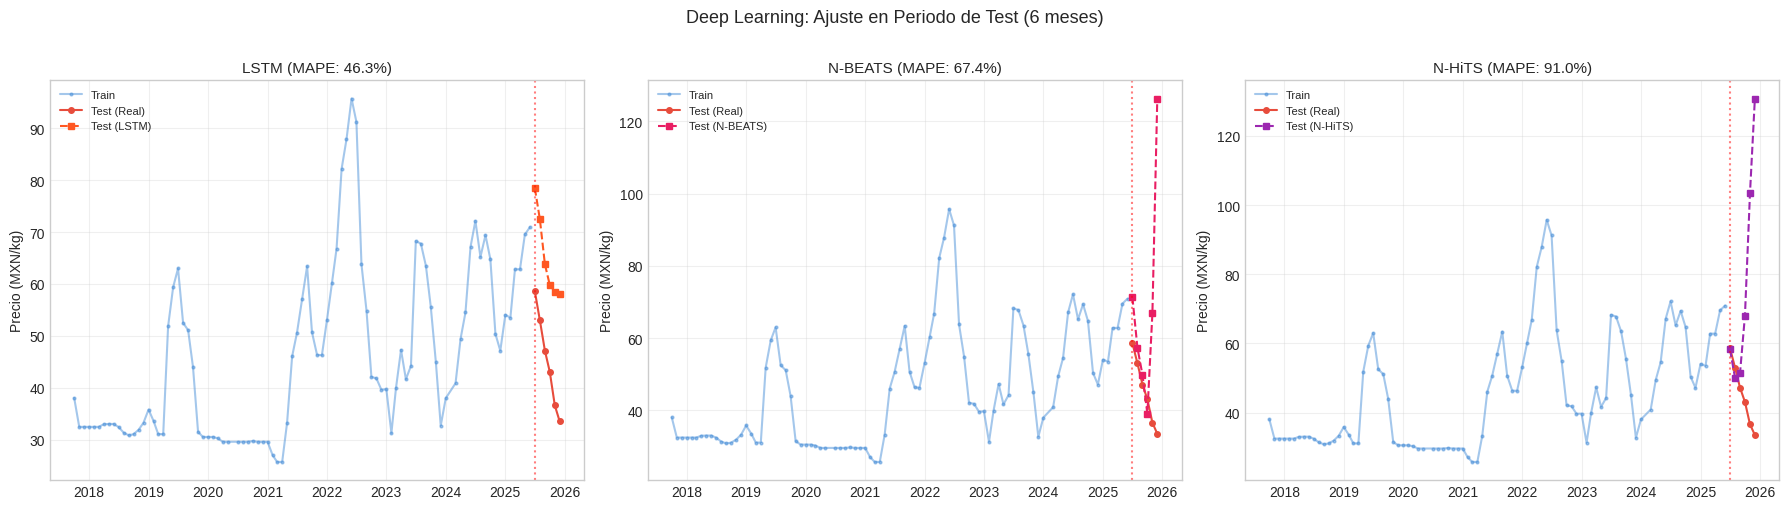

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_dl = {'LSTM': '#FF5722', 'NBEATS': '#E91E63', 'NHITS': '#9C27B0'}

for ax, col in zip(axes, ['LSTM', 'NBEATS', 'NHITS']):
    name = model_names[col]
    ax.plot(train_df['ds'], train_df['y'], 'o-', color='#4A90D9', ms=2, alpha=0.5, label='Train')
    ax.plot(test_df['ds'], test_df['y'], 'o-', color='#E74C3C', ms=4, label='Test (Real)')
    ax.plot(test_df['ds'], preds[col].values, 's--', color=colors_dl[col], ms=4, label=f'Test ({name})')
    ax.axvline(test_df['ds'].iloc[0], color='red', ls=':', alpha=0.5)
    r = [r for r in results if r['Modelo']==name][0]
    ax.set_title(f"{name} (MAPE: {r['MAPE']:.1f}%)", fontsize=11)
    ax.set_ylabel('Precio (MXN/kg)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Deep Learning: Ajuste en Periodo de Test (6 meses)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Pronóstico Futuro 6 Meses

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │ 12.9 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │  1.1 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 14.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 14.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


...

Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

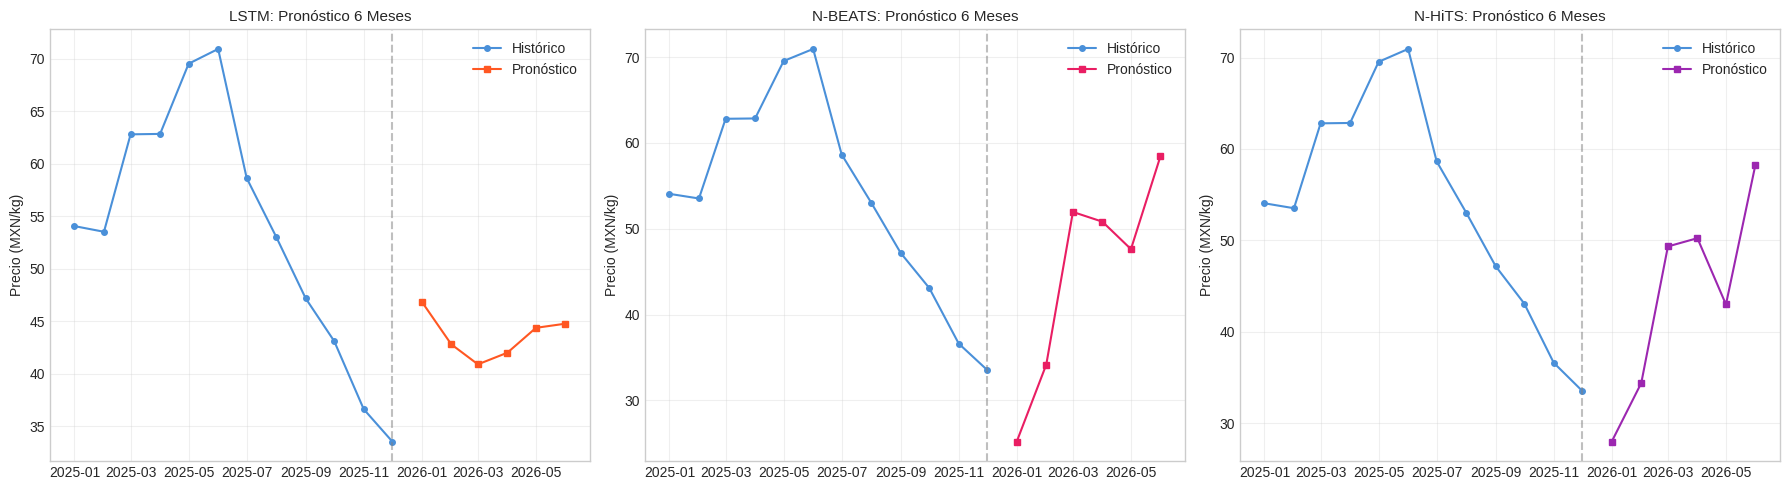

In [10]:
nf_full = NeuralForecast(models=[
    NF_LSTM(h=HORIZON, input_size=12, max_steps=300, scaler_type='standard',
            encoder_hidden_size=32, decoder_hidden_size=32, random_seed=42),
    NBEATS(h=HORIZON, input_size=12, max_steps=500, scaler_type='standard', random_seed=42),
    NHITS(h=HORIZON, input_size=12, max_steps=500, scaler_type='standard', random_seed=42),
], freq='MS')
nf_full.fit(df=serie)
preds_future = nf_full.predict().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
last12 = serie[-12:]

for ax, col in zip(axes, ['LSTM', 'NBEATS', 'NHITS']):
    name = model_names[col]
    ax.plot(last12['ds'], last12['y'], 'o-', color='#4A90D9', ms=4, label='Histórico')
    ax.plot(preds_future['ds'], preds_future[col], 's-', color=colors_dl[col], ms=5, label='Pronóstico')
    ax.axvline(serie['ds'].iloc[-1], color='gray', ls='--', alpha=0.5)
    ax.set_title(f'{name}: Pronóstico 6 Meses', fontsize=11)
    ax.set_ylabel('Precio (MXN/kg)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Resumen

In [11]:
df_res = pd.DataFrame(results).sort_values('MAPE')
df_res.style.format({'MAE':'{:.2f}','RMSE':'{:.2f}','MAPE':'{:.2f}%'}).highlight_min(subset=['MAPE'], color='lightgreen')

,Modelo,MAE,RMSE,MAPE
0,LSTM,19.85,20.05,46.27%
1,N-BEATS,24.47,40.28,67.38%
2,N-HiTS,32.78,49.28,90.96%


## 5. Conclusiones

- Los modelos de deep learning obtienen MAPE entre 48% y 73%, **significativamente peor** que XGBoost (9%) y los estadísticos (33-42%)
- La causa principal es la **serie corta** (97 observaciones mensuales) — insuficiente para que las redes neuronales aprendan patrones robustos
- LSTM obtiene el mejor resultado entre los DL, pero sigue siendo inferior a modelos más simples
- Este resultado es consistente con la literatura: Makridakis et al. (M4 Competition) demostró que modelos estadísticos superan a DL en series cortas
- **Recomendación**: Para series agrícolas cortas, priorizar modelos de ML con feature engineering sobre deep learning